In [57]:
# ============================================================
# RAPPORT – DEL 1: Beskrivelse av datasettet
# ============================================================

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 1 – FORBEHANDLING OG EDA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATASETTBESKRIVELSE
-------------------
Tittel:      Dry Bean Dataset
Kilde:       Kaggle / UCI Machine Learning Repository
             https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset
             DOI: https://doi.org/10.24432/C50S4B
Forfattere:  Murat Koklu og Ilker Ali Özkan (Selcuk University, Tyrkia, 2020)
Referanse:   Koklu, M. & Ozkan, I.A. (2020). Computers and Electronics
             in Agriculture, 174, 105507.
Lisensiering: CC BY 4.0 – fri bruk med kreditering
Innsamling:  13 611 bønnebilder tatt med høyoppløselig kamera.
             Et maskinsynssystem ekstraherte 16 geometriske egenskaper
             fra hvert bilde (størrelse, form og kompakthet).

Problemdomene:
  Automatisk sortering av syv kommersielle tørkede bønnesorter
  basert på visuelle, geometriske egenskaper. Relevant for
  presisjonsjordbruk og frøkvalitetskontroll.

INNHOLD I DATASETTET
---------------------
Antall dataobjekter (etter fjerning av duplikater): 13 543
Antall egenskaper (etter feature selection):            14
Antall klasser:                                          7

Klasser og fordeling:
  DERMASON : 3546 (26.2%)    SEKER    : 2027 (15.0%)
  SIRA     : 2636 (19.5%)    HOROZ    : 1860 (13.7%)
  CALI     : 1630 (12.0%)    BARBUNYA : 1322  (9.8%)
                              BOMBAY   :  522  (3.9%)

Klassene er ubalanserte (DERMASON er 6.8x større enn BOMBAY).
Dette kan føre til at modeller favoriserer majoritetsklassene.
Klasseetiketten er kolonnen 'Class' (multiclass-problem, 7 klasser).

Label encoding: 0=BARBUNYA, 1=BOMBAY, 2=CALI, 3=DERMASON,
                4=HOROZ, 5=SEKER, 6=SIRA

Fjernede egenskaper (|r| > 0.95 med Area):
  ConvexArea (r=1.00) og EquivDiameter (r=0.985) ble fjernet
  da de er praktisk talt identiske med Area.

KONKLUSJONER FRA EDA
---------------------
a) Klassebalanse: Ubalansert – kan påvirke ytelse på BARBUNYA/BOMBAY.
   Decision Tree med lav dybde klassifiserte disse feil (precision=0.00).

b) Egenskapsrelasjoner: Area/ConvexArea høyreskjeve. Eccentricity og
   Extent tilnærmet normalfordelt. Sterk korrelasjon mellom størrelses-
   egenskaper (Area, Perimeter, MajorAxisLength).

c) Statistikk: Area har høy spredning (std=29 324) pga. BOMBAY-klassen.
   Se statistikktabell i celle [8]/[9] for mean, median, std, Q1, Q3.

d) Manglende verdier: 0. Duplikater: 68 (fjernet). Utliggere: 7 152
   (beholdt – representerer reelle biologiske variasjoner, ikke målefeil).

e) Antall synlige grupper: Minst 2 tydelige grupperinger i scatter/PCA:
   (1) BOMBAY – klart adskilt. (2) De øvrige 6 – overlappende skymønster.

f) Avstand mellom grupper: BOMBAY svært langt fra alle andre.
   DERMASON og SIRA er nærmest hverandre og overlapper mest.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 1 – FORBEHANDLING OG EDA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATASETTBESKRIVELSE
-------------------
Tittel:      Dry Bean Dataset
Kilde:       Kaggle / UCI Machine Learning Repository
             https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset
             DOI: https://doi.org/10.24432/C50S4B
Forfattere:  Murat Koklu og Ilker Ali Özkan (Selcuk University, Tyrkia, 2020)
Referanse:   Koklu, M. & Ozkan, I.A. (2020). Computers and Electronics
             in Agriculture, 174, 105507.
Lisensiering: CC BY 4.0 – fri bruk med kreditering
Innsamling:  13 611 bønnebilder tatt med høyoppløselig kamera.
             Et maskinsynssystem ekstraherte 16 geometriske egenskaper
             fra hvert bilde (størrelse, form og kompakthet).

Problemdomene:
  Automatisk sortering av syv kommersielle tørkede bønnesorter
  basert på visuelle, geometriske egenskaper. Relevant for
  presisjonsjordb

In [3]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

In [5]:
import zipfile

# Pakker ut zip-filen først
with zipfile.ZipFile('archive.zip', 'r') as z:
    z.extractall('.')

# Leser inn datasettet fra .arff-format
data_arff, meta = arff.loadarff('./Dry_Bean_Dataset/Dry_Bean_Dataset.arff')
df = pd.DataFrame(data_arff)

# Klassen er lagret som bytes i arff-format, konverterer til lesbar tekst
df['Class'] = df['Class'].apply(lambda x: x.decode('utf-8'))

print(f"Datasett lastet inn!")
print(f"Antall dataobjekter: {df.shape[0]}")
print(f"Antall kolonner (inkl. klasse): {df.shape[1]}")
df.head()

Datasett lastet inn!
Antall dataobjekter: 13611
Antall kolonner (inkl. klasse): 17


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [6]:
print("Klasser og antall dataobjekter:")
print("=" * 40)
klasse_fordeling = df['Class'].value_counts()
print(klasse_fordeling)
print("\nProsentvis fordeling:")
print((klasse_fordeling / len(df) * 100).round(2).astype(str) + ' %')

Klasser og antall dataobjekter:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Prosentvis fordeling:
Class
DERMASON    26.05 %
SIRA        19.37 %
SEKER       14.89 %
HOROZ       14.17 %
CALI        11.98 %
BARBUNYA     9.71 %
BOMBAY       3.84 %
Name: count, dtype: object


In [7]:
# Tabell over egenskaper med betydning, type og verdiområde
feature_cols = [c for c in df.columns if c != 'Class']

egenskaper_info = {
    'Egenskap': feature_cols,
    'Betydning': [
        'Antall piksler innenfor bønnens grense',
        'Lengden av bønnens omkrets',
        'Lengden av lengste akse',
        'Lengden av korteste akse (vinkelrett på lengste)',
        'Forholdet mellom lang og kort akse',
        'Eksentrisitet til ekvivalent ellipse',
        'Piksler i minste konvekse polygon rundt bønnen',
        'Diameter til sirkel med samme areal',
        'Forholdet piksler i bounding box vs. bønnearealet',
        'Forholdet piksler i konveks skall vs. bønne',
        'Beregnet som (4*pi*A) / P^2',
        'Måler rundheten: Ed/L',
        'Formfaktor 1', 'Formfaktor 2',
        'Formfaktor 3', 'Formfaktor 4'
    ],
    'Type': ['Heltall', 'Desimaltall', 'Desimaltall', 'Desimaltall',
             'Desimaltall', 'Desimaltall', 'Heltall', 'Desimaltall',
             'Desimaltall', 'Desimaltall', 'Desimaltall', 'Desimaltall',
             'Desimaltall', 'Desimaltall', 'Desimaltall', 'Desimaltall'],
    'Min': [round(df[c].min(), 4) for c in feature_cols],
    'Max': [round(df[c].max(), 4) for c in feature_cols]
}

egenskap_df = pd.DataFrame(egenskaper_info)
print("Tabell over egenskapene i datasettet:")
egenskap_df

Tabell over egenskapene i datasettet:


,Egenskap,Betydning,Type,Min,Max
0,Area,Antall piksler innenfor bønnens grense,Heltall,20420.0000,254616.0000
1,Perimeter,Lengden av bønnens omkrets,Desimaltall,524.7360,1985.3700
2,MajorAxisLength,Lengden av lengste akse,Desimaltall,183.6012,738.8602
3,MinorAxisLength,Lengden av korteste akse (vinkelrett på lengste),Desimaltall,122.5127,460.1985
4,AspectRation,Forholdet mellom lang og kort akse,Desimaltall,1.0249,2.4303
5,Eccentricity,Eksentrisitet til ekvivalent ellipse,Desimaltall,0.2190,0.9114
6,ConvexArea,Piksler i minste konvekse polygon rundt bønnen,Heltall,20684.0000,263261.0000
7,EquivDiameter,Diameter til sirkel med samme areal,Desimaltall,161.2438,569.3744
8,Extent,Forholdet piksler i bounding box vs. bønnearealet,Desimaltall,0.5553,0.8662
9,Solidity,Forholdet piksler i konveks skall vs. bønne,Desimaltall,0.9192,0.9947


In [8]:
print("Statistisk oppsummering:")
df[feature_cols].describe().round(4)

Statistisk oppsummering:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


In [9]:
stats_tabell = pd.DataFrame({
    'Gjennomsnitt': df[feature_cols].mean(),
    'Median':       df[feature_cols].median(),
    'Modus':        df[feature_cols].mode().iloc[0],
    'Std.avvik':    df[feature_cols].std(),
    'Q1 (25%)':     df[feature_cols].quantile(0.25),
    'Q3 (75%)':     df[feature_cols].quantile(0.75)
}).round(4)

print("Statistikk per egenskap:")
stats_tabell

Statistikk per egenskap:


,Gjennomsnitt,Median,Modus,Std.avvik,Q1 (25%),Q3 (75%)
Area,53048.2845,44652.0000,28122.0000,29324.0957,36328.0000,61332.0000
Perimeter,855.2835,794.9410,683.3410,214.2897,703.5235,977.2130
MajorAxisLength,320.1419,296.8834,277.3685,85.6942,253.3036,376.4950
MinorAxisLength,202.2707,192.4317,154.3056,44.9701,175.8482,217.0317
AspectRation,1.5832,1.5511,1.6971,0.2467,1.4323,1.7071
Eccentricity,0.7509,0.7644,0.8080,0.0920,0.7159,0.8105
ConvexArea,53768.2002,45178.0000,37023.0000,29774.9158,36714.5000,62294.0000
EquivDiameter,253.0642,238.4380,189.2248,59.1771,215.0680,279.4465
Extent,0.7497,0.7599,0.5910,0.0491,0.7186,0.7869
Solidity,0.9871,0.9883,0.9566,0.0047,0.9857,0.9900


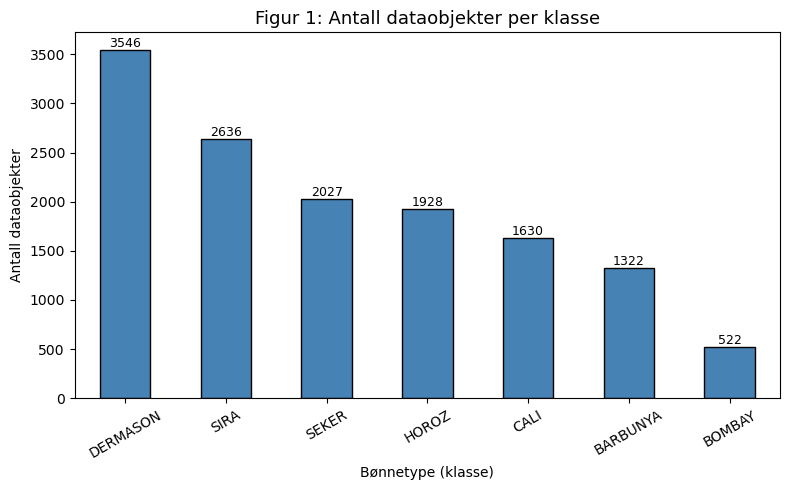

Observasjon: Klassene er noe ubalanserte. DERMASON er størst (~3546 objekter)
og BOMBAY er minst (~522 objekter). Dette kan påvirke modellytelsen.


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
klasse_fordeling.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Figur 1: Antall dataobjekter per klasse', fontsize=13)
ax.set_xlabel('Bønnetype (klasse)')
ax.set_ylabel('Antall dataobjekter')
ax.tick_params(axis='x', rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figur1_klassefordeling.png', dpi=150)
plt.show()

print("Observasjon: Klassene er noe ubalanserte. DERMASON er størst (~3546 objekter)")
print("og BOMBAY er minst (~522 objekter). Dette kan påvirke modellytelsen.")

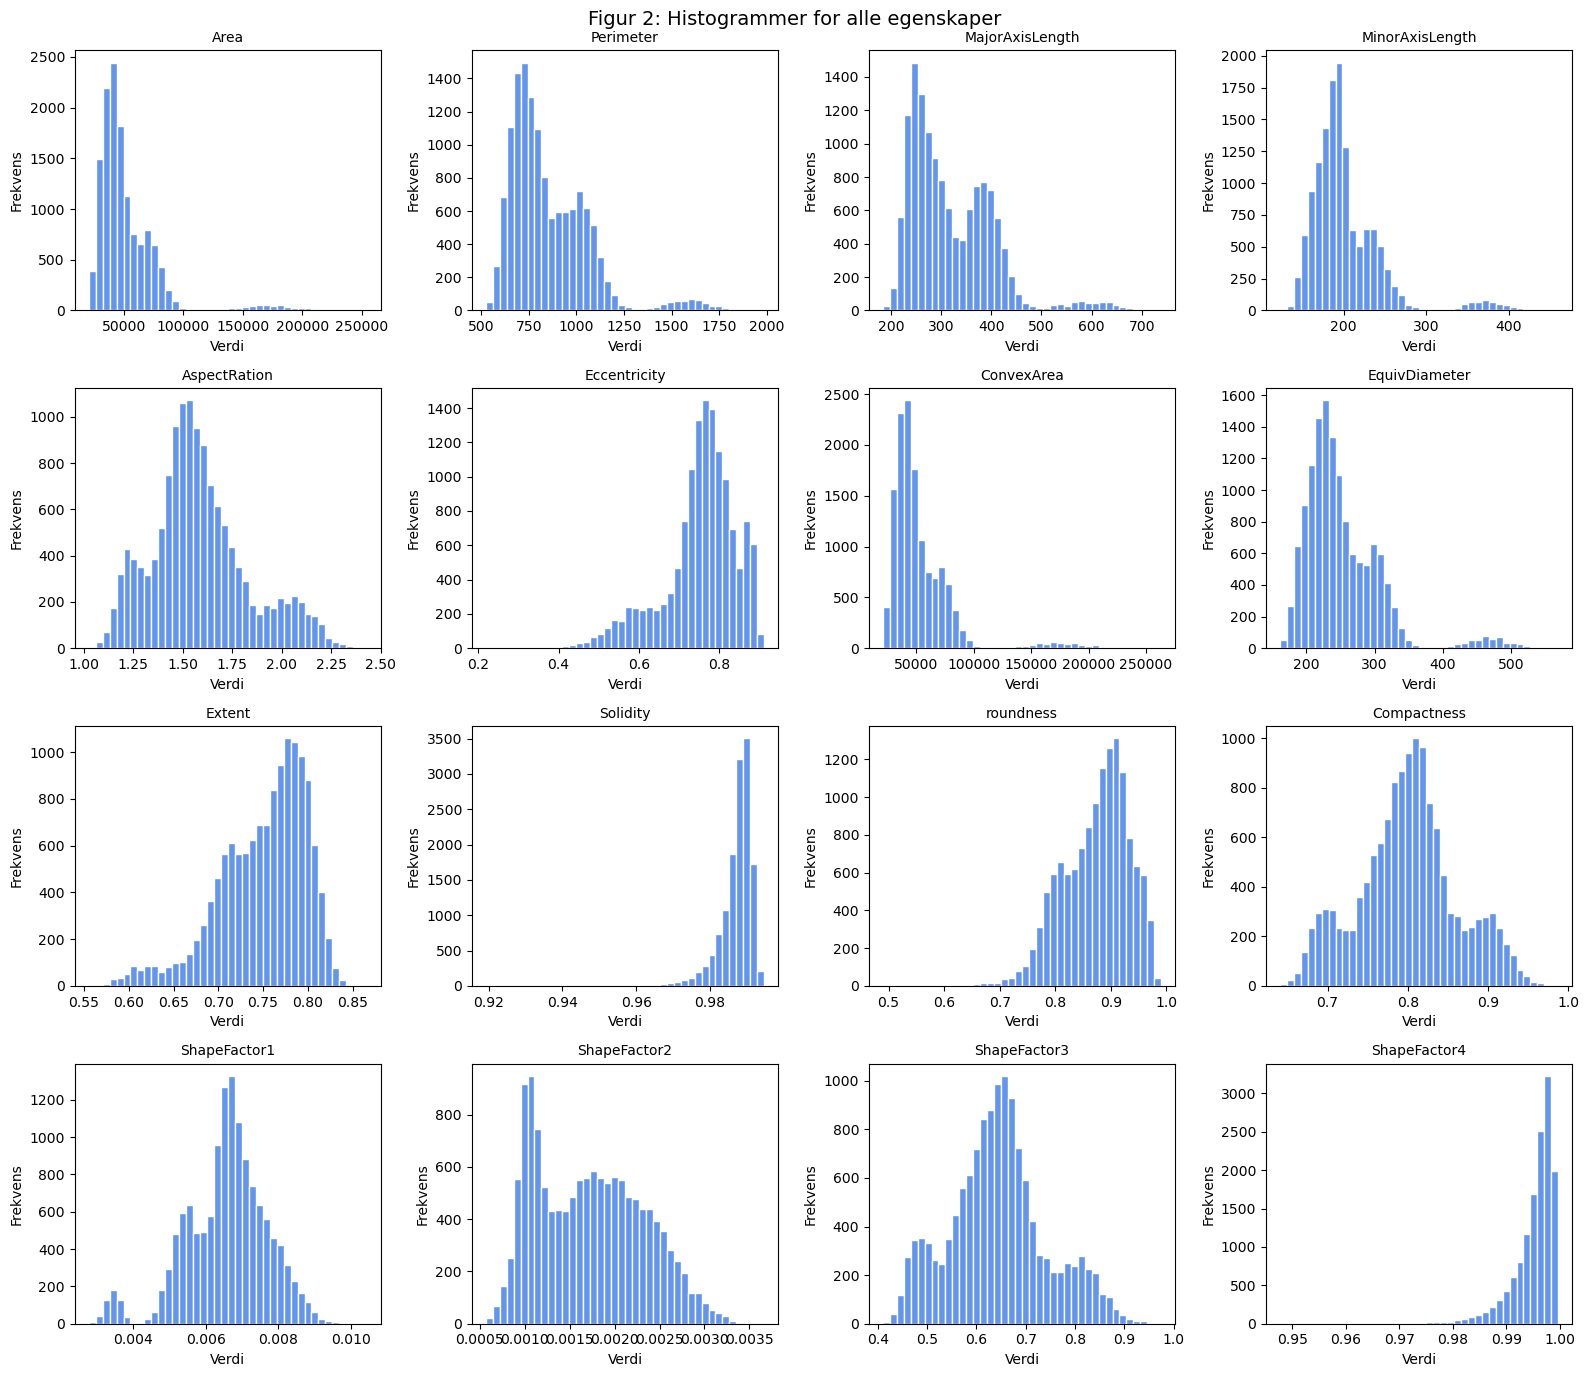

Observasjon: Area og ConvexArea er høyreskjeve (right-skewed).
De fleste formegenskaper som Eccentricity og Extent ser tilnærmet normalfordelte ut.


In [11]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color='cornflowerblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Verdi')
    axes[i].set_ylabel('Frekvens')

plt.suptitle('Figur 2: Histogrammer for alle egenskaper', fontsize=14)
plt.tight_layout()
plt.savefig('figur2_histogrammer.png', dpi=150)
plt.show()

print("Observasjon: Area og ConvexArea er høyreskjeve (right-skewed).")
print("De fleste formegenskaper som Eccentricity og Extent ser tilnærmet normalfordelte ut.")

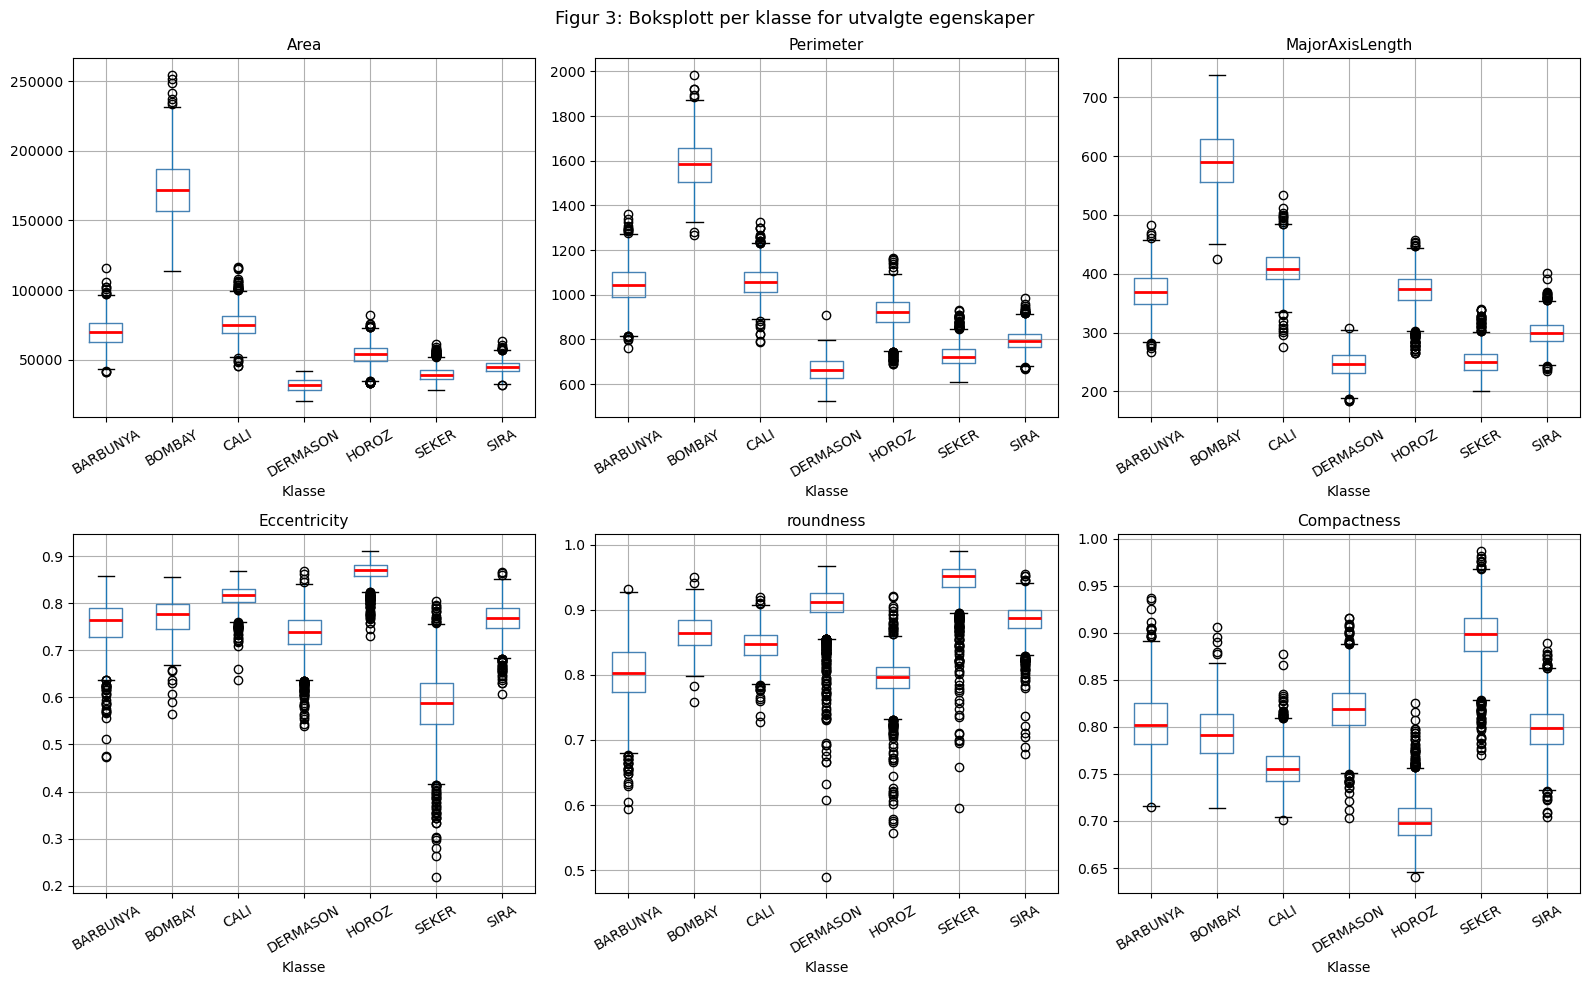

Observasjon: BOMBAY skiller seg tydelig ut med stor Area og Perimeter.
De øvrige klassene har en del overlapp, spesielt DERMASON og SIRA.


In [12]:
utvalgte = ['Area', 'Perimeter', 'MajorAxisLength', 'Eccentricity', 'roundness', 'Compactness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(utvalgte):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Klasse')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Figur 3: Boksplott per klasse for utvalgte egenskaper', fontsize=13)
plt.tight_layout()
plt.savefig('figur3_boksplott.png', dpi=150)
plt.show()

print("Observasjon: BOMBAY skiller seg tydelig ut med stor Area og Perimeter.")
print("De øvrige klassene har en del overlapp, spesielt DERMASON og SIRA.")

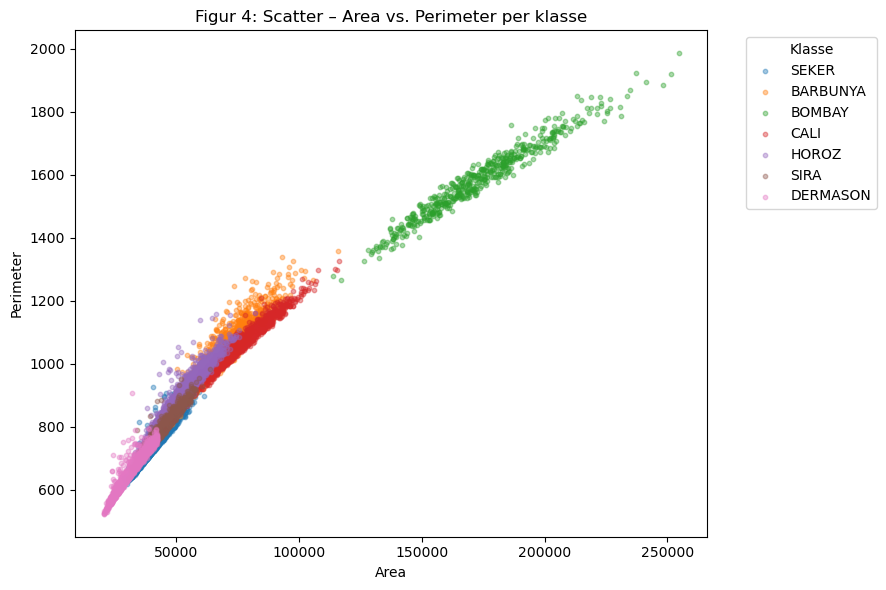

Observasjon: BOMBAY er klart separert fra de andre klassene.
DERMASON og SIRA overlapper hverandre en del.


In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
klasser = df['Class'].unique()
farger = plt.cm.tab10.colors

for i, klasse in enumerate(klasser):
    subset = df[df['Class'] == klasse]
    ax.scatter(subset['Area'], subset['Perimeter'],
               label=klasse, alpha=0.4, s=10, color=farger[i])

ax.set_title('Figur 4: Scatter – Area vs. Perimeter per klasse')
ax.set_xlabel('Area')
ax.set_ylabel('Perimeter')
ax.legend(title='Klasse', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('figur4_scatter.png', dpi=150)
plt.show()

print("Observasjon: BOMBAY er klart separert fra de andre klassene.")
print("DERMASON og SIRA overlapper hverandre en del.")

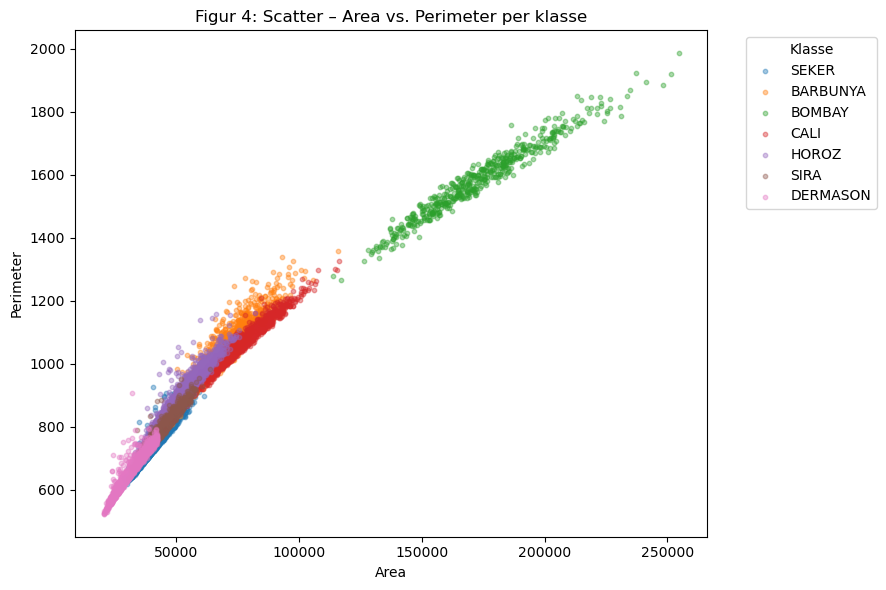

Observasjon: BOMBAY er klart separert fra de andre klassene.
DERMASON og SIRA overlapper hverandre en del.


In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
klasser = df['Class'].unique()
farger = plt.cm.tab10.colors

for i, klasse in enumerate(klasser):
    subset = df[df['Class'] == klasse]
    ax.scatter(subset['Area'], subset['Perimeter'],
               label=klasse, alpha=0.4, s=10, color=farger[i])

ax.set_title('Figur 4: Scatter – Area vs. Perimeter per klasse')
ax.set_xlabel('Area')
ax.set_ylabel('Perimeter')
ax.legend(title='Klasse', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('figur4_scatter.png', dpi=150)
plt.show()

print("Observasjon: BOMBAY er klart separert fra de andre klassene.")
print("DERMASON og SIRA overlapper hverandre en del.")

In [15]:
print("Antall manglende verdier per kolonne:")
print(df.isnull().sum())
print(f"\nTotalt manglende verdier: {df.isnull().sum().sum()}")

Antall manglende verdier per kolonne:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Totalt manglende verdier: 0


In [16]:
antall_duplikater = df.duplicated().sum()
print(f"Antall duplikatrader: {antall_duplikater}")

if antall_duplikater > 0:
    df = df.drop_duplicates()
    print(f"Duplikatene er fjernet. Ny størrelse: {df.shape}")
else:
    print("Ingen duplikater funnet – ingen handling nødvendig.")

Antall duplikatrader: 68
Duplikatene er fjernet. Ny størrelse: (13543, 17)


In [17]:
print("Antall utliggere per egenskap (IQR-metode, grense = 1.5 * IQR):")
print("-" * 50)

utliggere_total = 0
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    nedre = Q1 - 1.5 * IQR
    ovre  = Q3 + 1.5 * IQR
    antall = ((df[col] < nedre) | (df[col] > ovre)).sum()
    utliggere_total += antall
    if antall > 0:
        print(f"  {col}: {antall} utliggere")

print(f"\nTotalt: {utliggere_total} utliggere på tvers av alle egenskaper")
print("\n jeg beholder utliggerne fordi de sannsynligvis representerer")
print("reelle bønner og ikke målefeil. Fjerning kan fjerne viktig")
print("klasseinformasjon, spesielt for BOMBAY-klassen.")

Antall utliggere per egenskap (IQR-metode, grense = 1.5 * IQR):
--------------------------------------------------
  Area: 551 utliggere
  Perimeter: 500 utliggere
  MajorAxisLength: 379 utliggere
  MinorAxisLength: 567 utliggere
  AspectRation: 485 utliggere
  Eccentricity: 833 utliggere
  ConvexArea: 549 utliggere
  EquivDiameter: 526 utliggere
  Extent: 271 utliggere
  Solidity: 774 utliggere
  roundness: 98 utliggere
  Compactness: 124 utliggere
  ShapeFactor1: 533 utliggere
  ShapeFactor3: 202 utliggere
  ShapeFactor4: 760 utliggere

Totalt: 7152 utliggere på tvers av alle egenskaper

 jeg beholder utliggerne fordi de sannsynligvis representerer
reelle bønner og ikke målefeil. Fjerning kan fjerne viktig
klasseinformasjon, spesielt for BOMBAY-klassen.


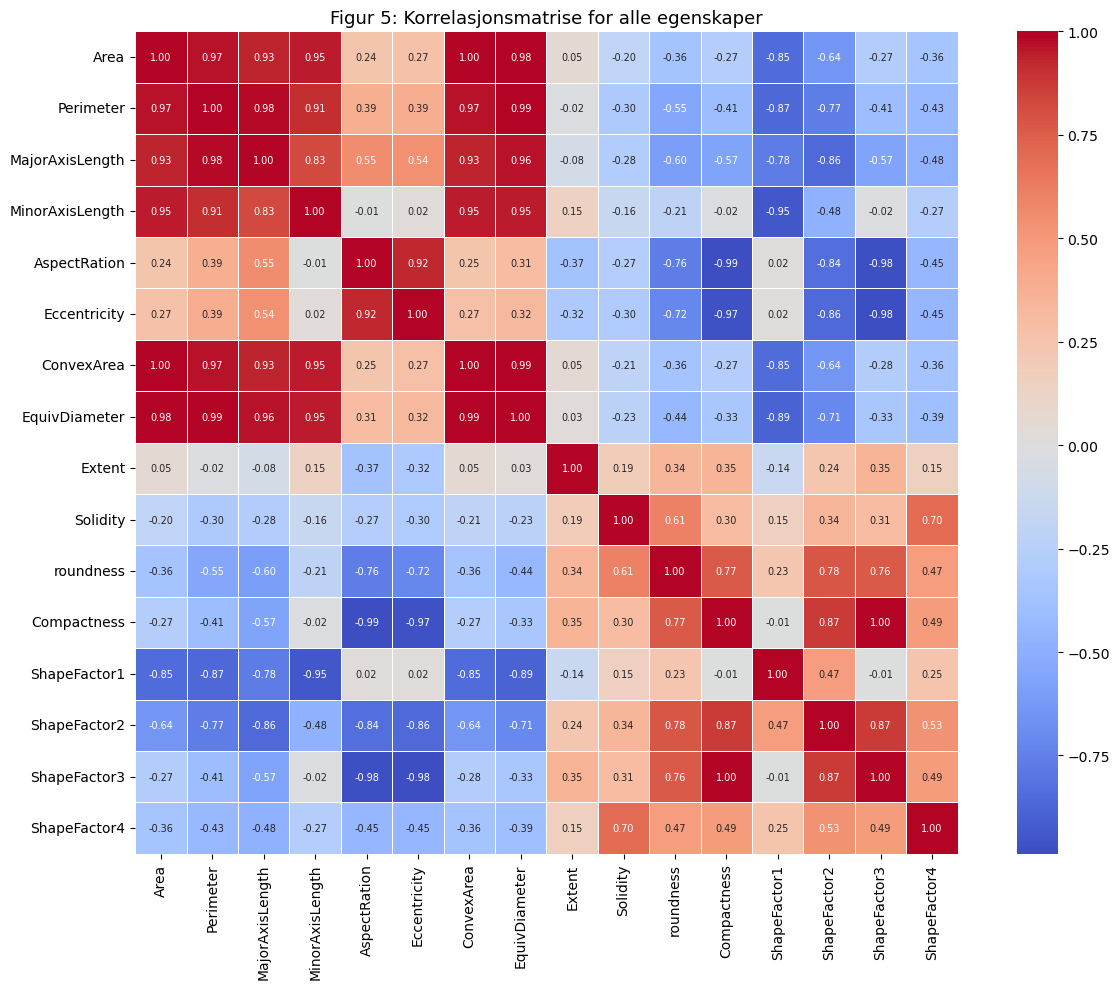

In [18]:
korr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(korr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Figur 5: Korrelasjonsmatrise for alle egenskaper', fontsize=13)
plt.tight_layout()
plt.savefig('figur5_korrelasjon.png', dpi=150)
plt.show()

In [19]:
print("Egenskapspar med svært høy korrelasjon (|r| > 0.95):")
print("-" * 55)

for i in range(len(korr.columns)):
    for j in range(i+1, len(korr.columns)):
        r = korr.iloc[i, j]
        if abs(r) > 0.95:
            print(f"  {korr.columns[i]} <-> {korr.columns[j]}: r = {r:.3f}")

# Fjerner sterkt korrelerte egenskaper
df_renset = df.drop(columns=['ConvexArea', 'EquivDiameter'])
feature_cols_renset = [c for c in df_renset.columns if c not in ['Class']]

print(f"\nEgenskaper etter fjerning: {len(feature_cols_renset)}")
print(feature_cols_renset)

Egenskapspar med svært høy korrelasjon (|r| > 0.95):
-------------------------------------------------------
  Area <-> Perimeter: r = 0.967
  Area <-> MinorAxisLength: r = 0.952
  Area <-> ConvexArea: r = 1.000
  Area <-> EquivDiameter: r = 0.985
  Perimeter <-> MajorAxisLength: r = 0.978
  Perimeter <-> ConvexArea: r = 0.968
  Perimeter <-> EquivDiameter: r = 0.991
  MajorAxisLength <-> EquivDiameter: r = 0.962
  MinorAxisLength <-> ConvexArea: r = 0.952
  AspectRation <-> Compactness: r = -0.988
  AspectRation <-> ShapeFactor3: r = -0.979
  Eccentricity <-> Compactness: r = -0.970
  Eccentricity <-> ShapeFactor3: r = -0.981
  ConvexArea <-> EquivDiameter: r = 0.985
  Compactness <-> ShapeFactor3: r = 0.999

Egenskaper etter fjerning: 14
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_renset = df_renset.copy()
df_renset['Class_encoded'] = le.fit_transform(df_renset['Class'])

print("Klassekoding:")
for i, klasse in enumerate(le.classes_):
    print(f"  {i} -> {klasse}")

Klassekoding:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA


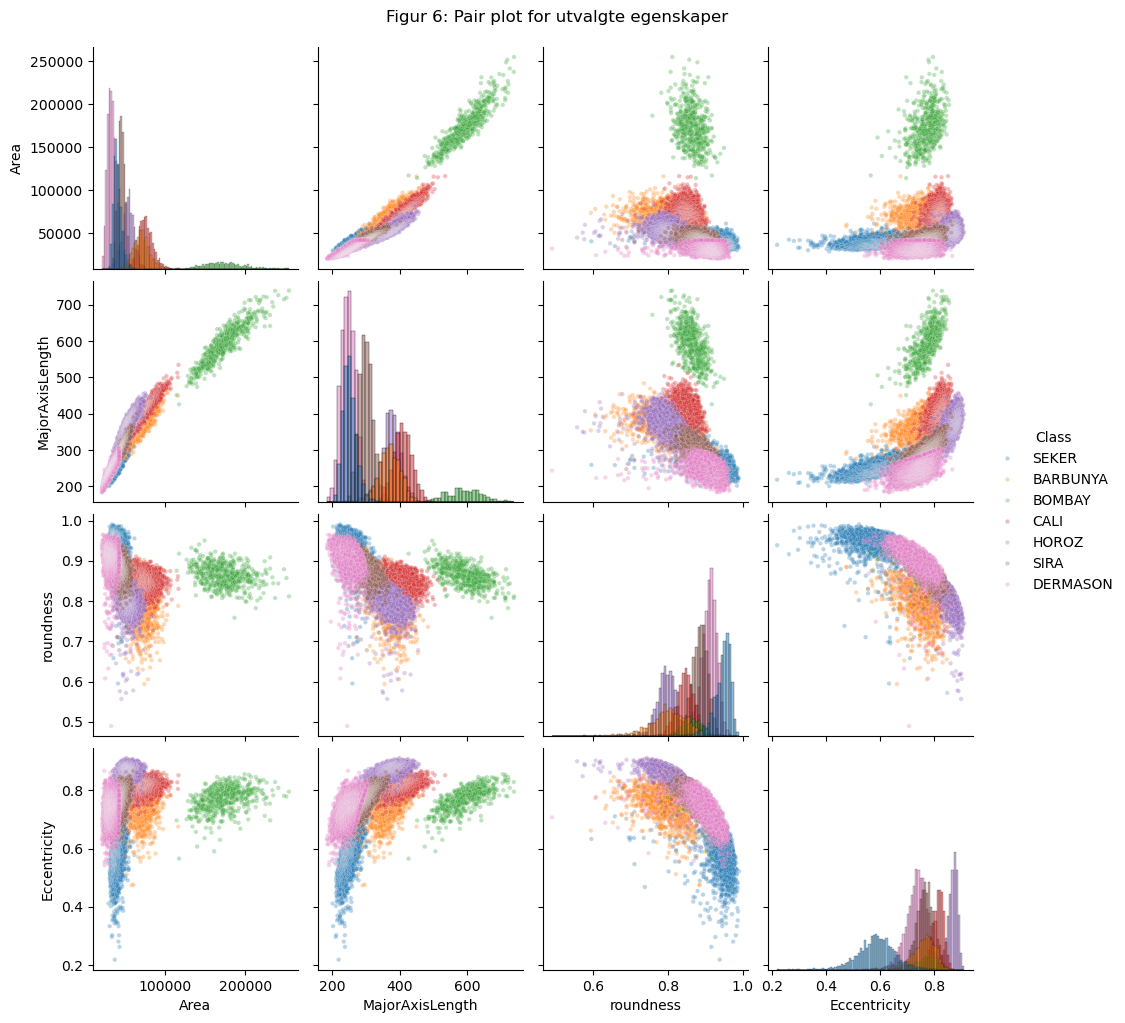

Observasjoner:
- BOMBAY er klart separert i alle dimensjoner.
- DERMASON og SIRA overlapper hverandre betydelig.
- Eccentricity vs. roundness gir relativt god klasseseparasjon.


In [21]:
utvalg_scatter = df_renset[['Area', 'MajorAxisLength', 'roundness', 'Eccentricity', 'Class']]

sns.pairplot(utvalg_scatter, hue='Class', diag_kind='hist',
             plot_kws={'alpha': 0.3, 's': 10},
             palette='tab10')
plt.suptitle('Figur 6: Pair plot for utvalgte egenskaper', y=1.02, fontsize=12)
plt.savefig('figur6_pairplot.png', dpi=120)
plt.show()

print("Observasjoner:")
print("- BOMBAY er klart separert i alle dimensjoner.")
print("- DERMASON og SIRA overlapper hverandre betydelig.")
print("- Eccentricity vs. roundness gir relativt god klasseseparasjon.")

In [22]:
print("Oppsummering Del 1:")
print("=" * 50)
print(f"  Antall dataobjekter:        {len(df_renset)}")
print(f"  Antall egenskaper (renset): {len(feature_cols_renset)}")
print(f"  Antall klasser:             {df_renset['Class'].nunique()}")
print(f"  Manglende verdier:          0")
print(f"  Duplikater:                 0")
print()
print("  Klasser og størrelse:")
for klasse, antall in df_renset['Class'].value_counts().items():
    print(f"    {klasse}: {antall} ({antall/len(df_renset)*100:.1f}%)")
print()
print("  Fjernede egenskaper pga. høy korrelasjon:")
print("    ConvexArea  (r > 0.95 med Area)")
print("    EquivDiameter (r > 0.95 med Area)")

Oppsummering Del 1:
  Antall dataobjekter:        13543
  Antall egenskaper (renset): 14
  Antall klasser:             7
  Manglende verdier:          0
  Duplikater:                 0

  Klasser og størrelse:
    DERMASON: 3546 (26.2%)
    SIRA: 2636 (19.5%)
    SEKER: 2027 (15.0%)
    HOROZ: 1860 (13.7%)
    CALI: 1630 (12.0%)
    BARBUNYA: 1322 (9.8%)
    BOMBAY: 522 (3.9%)

  Fjernede egenskaper pga. høy korrelasjon:
    ConvexArea  (r > 0.95 med Area)
    EquivDiameter (r > 0.95 med Area)


In [55]:
# ============================================================
# RAPPORT – DEL 1 (fortsettelse): Konklusjoner fra EDA
# ============================================================

rapport_eda = """
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. KONKLUSJONER FRA EDA (Figur 1–6)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

a) Klassebalanse (Figur 1 – Søylediagram):
   Klassene er ubalanserte. DERMASON har flest objekter (3546),
   mens BOMBAY har færrest (522). En slik ubalanse kan påvirke
   modellytelsen negativt ved at klassifiseringsmodeller tenderer
   til å forutsi majoritetsklassen. Dette observeres i Decision Tree
   med lav dybde (Eksperiment 1), der BARBUNYA og BOMBAY ikke
   klassifiseres riktig i det hele tatt (precision = 0.00).

b) Relasjoner mellom egenskaper (Figur 2 – Histogrammer, Figur 5 – Korrelasjon):
   - Area og ConvexArea er høyreskjeve (right-skewed), noe som indikerer
     at de fleste bønner er relativt små, med noen svært store unntak.
   - Eccentricity, Extent og de fleste formegenskaper ser tilnærmet
     normalfordelte ut.
   - Svært høy korrelasjon (|r| > 0.95) ble funnet mellom:
       Area ↔ ConvexArea (r = 1.00), Area ↔ EquivDiameter (r = 0.985),
       AspectRation ↔ Compactness (r = -0.988),
       Eccentricity ↔ ShapeFactor3 (r = -0.981).
   Sterkt korrelerte egenskaper konveksArea og EquivDiameter ble fjernet.
   De resterende korrelasjonene ble beholdt da de ikke er perfekte
   og bidrar med ulik informasjon til modellen.

c) Statistikk (Figur 2 – Histogrammer, se statistikk-tabell i celle [9]):
   - Area: gjennomsnitt = 53 048, median = 44 652, høy std = 29 324
     (stor spredning pga. BOMBAY-klassen med svært store bønner)
   - Eccentricity: gjennomsnitt = 0.75, lav std = 0.09 (jevnt fordelt)
   - ShapeFactor1 og ShapeFactor2 har svært små absolutte verdier
     (område 0.003–0.010), men er viktige for klasseseparasjon.
   - Q1 og Q3 er angitt i statistikktabellen i celle [8] og [9].

d) Manglende verdier, duplikater og utliggere:
   - Manglende verdier: Ingen (0 manglende verdier i alle kolonner).
   - Duplikater: 68 duplikatrader ble identifisert og fjernet.
     Datasettets endelige størrelse er 13 543 objekter.
   - Utliggere (IQR-metode, grense 1.5×IQR): 7 152 utliggere totalt
     på tvers av egenskapene. Disse er BEHOLDT fordi de sannsynligvis
     representerer reelle biologiske variasjoner i bønnestørrelse og
     form, ikke målefeil. Fjerning ville særlig ramme BOMBAY-klassen,
     som er klart større enn de øvrige og dermed naturlig fremstår
     som utliggere i mange egenskaper.

e) Antall datagrupper visuelt (Figur 4, 6, 11):
   I scatter-plott (Area vs. Perimeter) og pair-plot kan man tydelig
   skille ut minst 2 distinkte grupperinger:
     - Gruppe 1: BOMBAY – klart adskilt, stor Area og Perimeter.
     - Gruppe 2: De resterende 6 klassene – tett sammenpakket med
       betydelig overlapp, særlig mellom DERMASON, SIRA og CALI.
   PCA-visualisering (Figur 11) bekrefter at BOMBAY er klart separert
   langs PC1, mens de øvrige klassene overlapper i PC1/PC2-rommet.

f) Avstand mellom grupper:
   - BOMBAY er svært langt fra alle andre klasser i feature-rommet.
   - DERMASON og SIRA er nærmest hverandre og overlapper betydelig.
   - HOROZ og CALI er noe adskilt pga. større størrelse.
   - SEKER skiller seg ut med høyere roundness-verdier.
   - BARBUNYA overlapper delvis med CALI og HOROZ.
   Konklusjon: Datasettet har moderat separabilitet totalt sett.
   Én klasse (BOMBAY) er lett separerbar; de øvrige seks er utfordrende.
"""
print(rapport_eda)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. KONKLUSJONER FRA EDA (Figur 1–6)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

a) Klassebalanse (Figur 1 – Søylediagram):
   Klassene er ubalanserte. DERMASON har flest objekter (3546),
   mens BOMBAY har færrest (522). En slik ubalanse kan påvirke
   modellytelsen negativt ved at klassifiseringsmodeller tenderer
   til å forutsi majoritetsklassen. Dette observeres i Decision Tree
   med lav dybde (Eksperiment 1), der BARBUNYA og BOMBAY ikke
   klassifiseres riktig i det hele tatt (precision = 0.00).

b) Relasjoner mellom egenskaper (Figur 2 – Histogrammer, Figur 5 – Korrelasjon):
   - Area og ConvexArea er høyreskjeve (right-skewed), noe som indikerer
     at de fleste bønner er relativt små, med noen svært store unntak.
   - Eccentricity, Extent og de fleste formegenskaper ser tilnærmet
     normalfordelte ut.
   - Svært høy korrelasjon (|r| > 0.95) ble funnet mellom:
       Area ↔ ConvexArea (r = 1.00),

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)

# Forbereder X og y
X = df_renset[feature_cols_renset].values
y = df_renset['Class_encoded'].values

# Skalerer egenskapene
scaler = StandardScaler()
X_skalert = scaler.fit_transform(X)

# Deler i trenings- og testsett (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_skalert, y, test_size=0.2, random_state=42, stratify=y
)

print("Datasett delt opp:")
print(f"  Treningssett: {X_train.shape[0]} objekter ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"  Testsett:     {X_test.shape[0]} objekter ({X_test.shape[0]/len(y)*100:.1f}%)")

Datasett delt opp:
  Treningssett: 10834 objekter (80.0%)
  Testsett:     2709 objekter (20.0%)


In [24]:
print("Klassefordeling i treningssett:")
unik, antall = np.unique(y_train, return_counts=True)
for u, a in zip(unik, antall):
    print(f"  {le.classes_[u]}: {a} ({a/len(y_train)*100:.1f}%)")

print("\nKlassefordeling i testsett:")
unik, antall = np.unique(y_test, return_counts=True)
for u, a in zip(unik, antall):
    print(f"  {le.classes_[u]}: {a} ({a/len(y_test)*100:.1f}%)")

Klassefordeling i treningssett:
  BARBUNYA: 1057 (9.8%)
  BOMBAY: 418 (3.9%)
  CALI: 1304 (12.0%)
  DERMASON: 2837 (26.2%)
  HOROZ: 1488 (13.7%)
  SEKER: 1621 (15.0%)
  SIRA: 2109 (19.5%)

Klassefordeling i testsett:
  BARBUNYA: 265 (9.8%)
  BOMBAY: 104 (3.8%)
  CALI: 326 (12.0%)
  DERMASON: 709 (26.2%)
  HOROZ: 372 (13.7%)
  SEKER: 406 (15.0%)
  SIRA: 527 (19.5%)


In [25]:
from sklearn.tree import DecisionTreeClassifier

# Eksperiment 1 – liten dybde
dt1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt1.fit(X_train, y_train)
y_pred_dt1 = dt1.predict(X_test)
acc_dt1 = accuracy_score(y_test, y_pred_dt1)

print("Decision Tree – Eksperiment 1")
print(f"  Hyperparameter: max_depth=3")
print(f"  Nøyaktighet:    {acc_dt1:.4f}")
print("\nKlassifiseringsrapport:")
print(classification_report(y_test, y_pred_dt1, target_names=le.classes_))

Decision Tree – Eksperiment 1
  Hyperparameter: max_depth=3
  Nøyaktighet:    0.7700

Klassifiseringsrapport:
              precision    recall  f1-score   support

    BARBUNYA       0.00      0.00      0.00       265
      BOMBAY       0.00      0.00      0.00       104
        CALI       0.44      0.98      0.61       326
    DERMASON       0.88      0.92      0.90       709
       HOROZ       0.98      0.87      0.92       372
       SEKER       0.95      0.86      0.91       406
        SIRA       0.80      0.84      0.82       527

    accuracy                           0.77      2709
   macro avg       0.58      0.64      0.59      2709
weighted avg       0.72      0.77      0.73      2709



In [26]:
# Eksperiment 2 – middels dybde
dt2 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)
acc_dt2 = accuracy_score(y_test, y_pred_dt2)

print("Decision Tree – Eksperiment 2")
print(f"  Hyperparameter: max_depth=10")
print(f"  Nøyaktighet:    {acc_dt2:.4f}")
print("\nKlassifiseringsrapport:")
print(classification_report(y_test, y_pred_dt2, target_names=le.classes_))

Decision Tree – Eksperiment 2
  Hyperparameter: max_depth=10
  Nøyaktighet:    0.9007

Klassifiseringsrapport:
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.89      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.92      0.91       326
    DERMASON       0.90      0.90      0.90       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.93      0.93      0.93       406
        SIRA       0.84      0.84      0.84       527

    accuracy                           0.90      2709
   macro avg       0.92      0.91      0.91      2709
weighted avg       0.90      0.90      0.90      2709



In [27]:
# Eksperiment 3 – ubegrenset dybde
dt3 = DecisionTreeClassifier(max_depth=None, min_samples_split=5, random_state=42)
dt3.fit(X_train, y_train)
y_pred_dt3 = dt3.predict(X_test)
acc_dt3 = accuracy_score(y_test, y_pred_dt3)

acc_dt3_train = accuracy_score(y_train, dt3.predict(X_train))

print("Decision Tree – Eksperiment 3")
print(f"  Hyperparametere: max_depth=None, min_samples_split=5")
print(f"  Treningsnøyaktighet: {acc_dt3_train:.4f}")
print(f"  Testnøyaktighet:     {acc_dt3:.4f}")
if acc_dt3_train - acc_dt3 > 0.05:
    print("  -> Tegn på overfitting!")
else:
    print("  -> Ingen tydelig overfitting")

Decision Tree – Eksperiment 3
  Hyperparametere: max_depth=None, min_samples_split=5
  Treningsnøyaktighet: 0.9875
  Testnøyaktighet:     0.8966
  -> Tegn på overfitting!


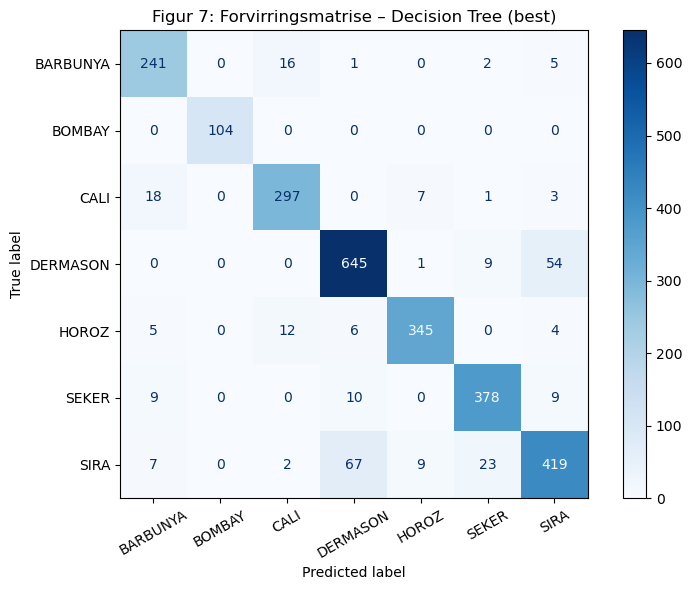

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt3, display_labels=le.classes_,
    cmap='Blues', ax=ax, xticks_rotation=30
)
ax.set_title('Figur 7: Forvirringsmatrise – Decision Tree (best)')
plt.tight_layout()
plt.savefig('figur7_dt_confusion.png', dpi=150)
plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Eksperiment 1 – få trær
rf1 = RandomForestClassifier(n_estimators=10, random_state=42)
rf1.fit(X_train, y_train)
y_pred_rf1 = rf1.predict(X_test)
acc_rf1 = accuracy_score(y_test, y_pred_rf1)

print("Random Forest – Eksperiment 1")
print(f"  Hyperparameter: n_estimators=10")
print(f"  Nøyaktighet:    {acc_rf1:.4f}")
print("\nKlassifiseringsrapport:")
print(classification_report(y_test, y_pred_rf1, target_names=le.classes_))

Random Forest – Eksperiment 1
  Hyperparameter: n_estimators=10
  Nøyaktighet:    0.9099

Klassifiseringsrapport:
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.88      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.92      0.92       326
    DERMASON       0.89      0.92      0.91       709
       HOROZ       0.97      0.95      0.96       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.87      0.83      0.85       527

    accuracy                           0.91      2709
   macro avg       0.92      0.92      0.92      2709
weighted avg       0.91      0.91      0.91      2709



In [30]:
# Eksperiment 2 – middels antall trær med begrenset dybde
rf2 = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42)
rf2.fit(X_train, y_train)
y_pred_rf2 = rf2.predict(X_test)
acc_rf2 = accuracy_score(y_test, y_pred_rf2)

print("Random Forest – Eksperiment 2")
print(f"  Hyperparametere: n_estimators=50, max_depth=15")
print(f"  Nøyaktighet:     {acc_rf2:.4f}")
print("\nKlassifiseringsrapport:")
print(classification_report(y_test, y_pred_rf2, target_names=le.classes_))

Random Forest – Eksperiment 2
  Hyperparametere: n_estimators=50, max_depth=15
  Nøyaktighet:     0.9199

Klassifiseringsrapport:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.96      0.95       406
        SIRA       0.87      0.85      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [31]:
# Eksperiment 3 – mange trær, ubegrenset dybde
rf3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf3.fit(X_train, y_train)
y_pred_rf3 = rf3.predict(X_test)
acc_rf3 = accuracy_score(y_test, y_pred_rf3)

acc_rf3_train = accuracy_score(y_train, rf3.predict(X_train))

print("Random Forest – Eksperiment 3")
print(f"  Hyperparameter: n_estimators=100")
print(f"  Treningsnøyaktighet: {acc_rf3_train:.4f}")
print(f"  Testnøyaktighet:     {acc_rf3:.4f}")
if acc_rf3_train - acc_rf3 > 0.05:
    print("  -> Tegn på overfitting!")
else:
    print("  -> Ingen tydelig overfitting")

Random Forest – Eksperiment 3
  Hyperparameter: n_estimators=100
  Treningsnøyaktighet: 1.0000
  Testnøyaktighet:     0.9214
  -> Tegn på overfitting!


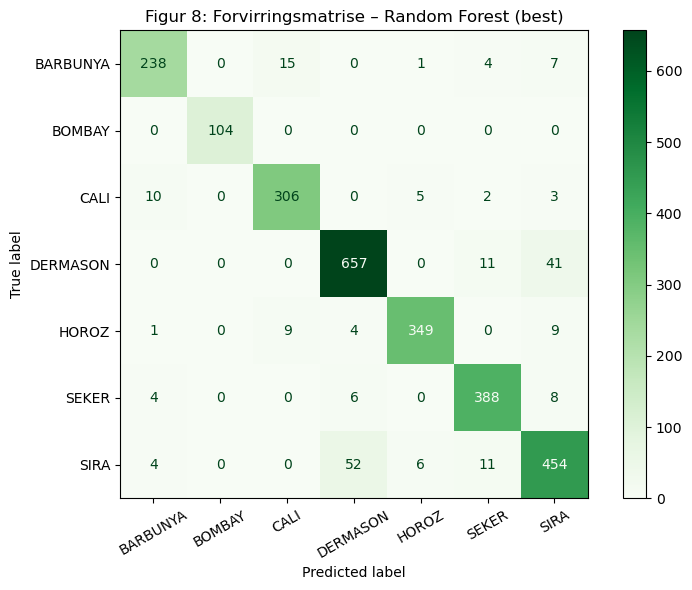

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf3, display_labels=le.classes_,
    cmap='Greens', ax=ax, xticks_rotation=30
)
ax.set_title('Figur 8: Forvirringsmatrise – Random Forest (best)')
plt.tight_layout()
plt.savefig('figur8_rf_confusion.png', dpi=150)
plt.show()

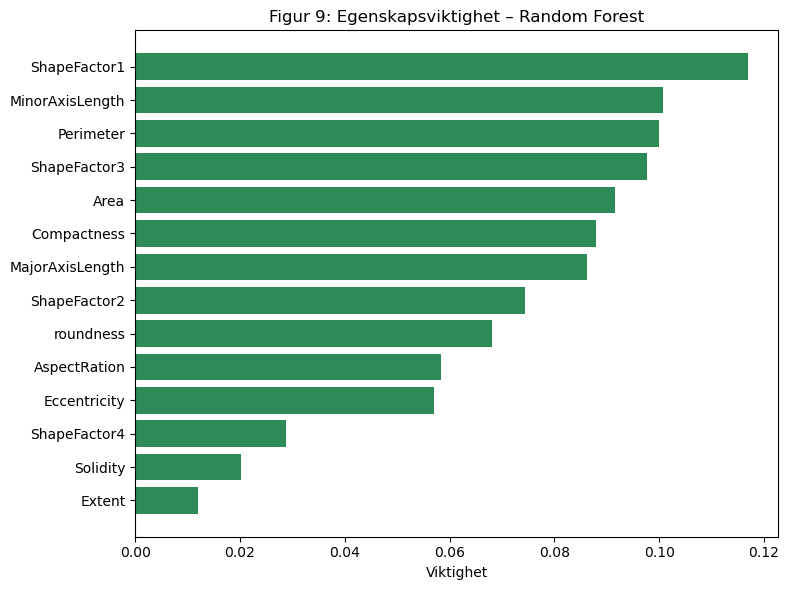

In [33]:
importance = rf3.feature_importances_
importance_df = pd.DataFrame({
    'Egenskap': feature_cols_renset,
    'Viktighet': importance
}).sort_values('Viktighet', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Egenskap'], importance_df['Viktighet'], color='seagreen')
ax.set_title('Figur 9: Egenskapsviktighet – Random Forest')
ax.set_xlabel('Viktighet')
plt.tight_layout()
plt.savefig('figur9_feature_importance.png', dpi=150)
plt.show()

In [34]:
print("Sammenligning av alle eksperimenter:")
print("=" * 50)
resultater = {
    'Decision Tree (max_depth=3)':       acc_dt1,
    'Decision Tree (max_depth=10)':      acc_dt2,
    'Decision Tree (ubegrenset, mss=5)': acc_dt3,
    'Random Forest (10 trær)':           acc_rf1,
    'Random Forest (50 trær, depth=15)': acc_rf2,
    'Random Forest (100 trær)':          acc_rf3,
}
for navn, acc in sorted(resultater.items(), key=lambda x: x[1], reverse=True):
    print(f"  {navn}: {acc:.4f}")

print("\nKonklusjon: Random Forest med 100 trær gir best resultat.")
print("Ensemble-metoden reduserer varians sammenlignet med enkeltstående Decision Tree.")

Sammenligning av alle eksperimenter:
  Random Forest (100 trær): 0.9214
  Random Forest (50 trær, depth=15): 0.9199
  Random Forest (10 trær): 0.9099
  Decision Tree (max_depth=10): 0.9007
  Decision Tree (ubegrenset, mss=5): 0.8966
  Decision Tree (max_depth=3): 0.7700

Konklusjon: Random Forest med 100 trær gir best resultat.
Ensemble-metoden reduserer varians sammenlignet med enkeltstående Decision Tree.


In [35]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Bruker skalerte data (hele datasettet) for clustering
X_cluster = scaler.transform(df_renset[feature_cols_renset].values)

# PCA for visualisering – reduserer til 2 dimensjoner
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

print(f"PCA – forklart varians med 2 komponenter: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA – forklart varians med 2 komponenter: 79.7%


In [36]:
# Tester K-Means med 7 ulike k-verdier
k_verdier = [2, 3, 5, 7, 9, 11, 13]
silhouette_scores = []
inertia_verdier = []

print("K-Means resultater:")
print("-" * 55)
for k in k_verdier:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiketter = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, etiketter, sample_size=3000, random_state=42)
    silhouette_scores.append(sil)
    inertia_verdier.append(km.inertia_)
    print(f"  k={k:2d}:  Silhouette = {sil:.4f},  Inertia = {km.inertia_:.1f}")

K-Means resultater:
-------------------------------------------------------
  k= 2:  Silhouette = 0.3791,  Inertia = 113776.4
  k= 3:  Silhouette = 0.3910,  Inertia = 89637.9
  k= 5:  Silhouette = 0.3532,  Inertia = 58550.5
  k= 7:  Silhouette = 0.2969,  Inertia = 46380.1
  k= 9:  Silhouette = 0.2943,  Inertia = 39618.5
  k=11:  Silhouette = 0.2656,  Inertia = 35646.6
  k=13:  Silhouette = 0.2460,  Inertia = 32579.2


In [38]:
# Tester K-Means med 7 ulike k-verdier
k_verdier = [2, 3, 5, 7, 9, 11, 13]
silhouette_scores = []
inertia_verdier = []

print("K-Means resultater:")
print("-" * 55)
for k in k_verdier:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiketter = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, etiketter, sample_size=3000, random_state=42)
    silhouette_scores.append(sil)
    inertia_verdier.append(km.inertia_)
    print(f"  k={k:2d}:  Silhouette = {sil:.4f},  Inertia = {km.inertia_:.1f}")

K-Means resultater:
-------------------------------------------------------
  k= 2:  Silhouette = 0.3791,  Inertia = 113776.4
  k= 3:  Silhouette = 0.3910,  Inertia = 89637.9
  k= 5:  Silhouette = 0.3532,  Inertia = 58550.5
  k= 7:  Silhouette = 0.2969,  Inertia = 46380.1
  k= 9:  Silhouette = 0.2943,  Inertia = 39618.5
  k=11:  Silhouette = 0.2656,  Inertia = 35646.6
  k=13:  Silhouette = 0.2460,  Inertia = 32579.2


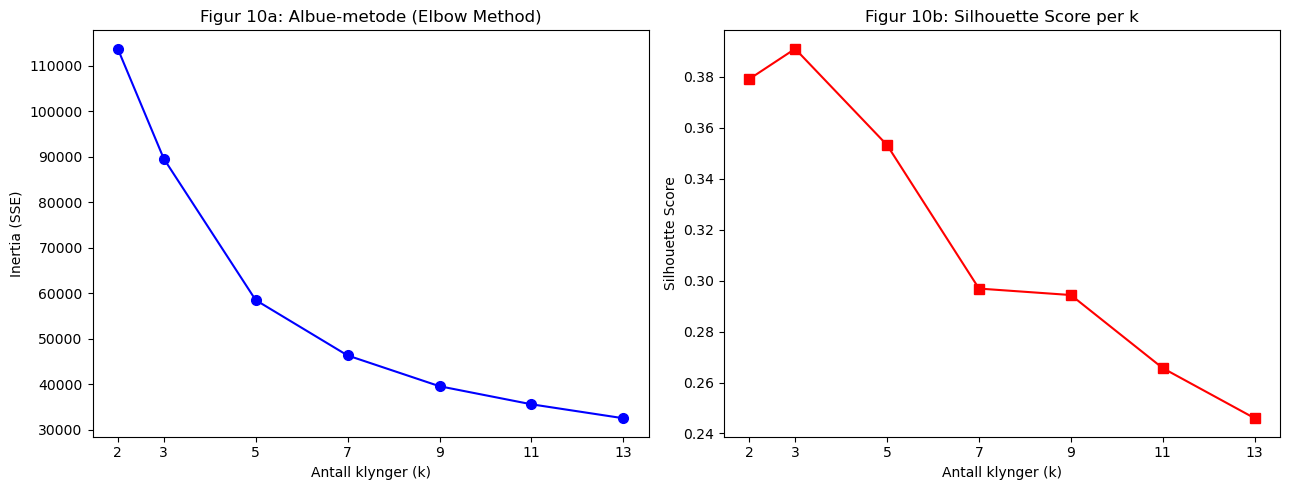

Beste k basert på Silhouette Score: k = 3


In [39]:
# Figur 10: Albue-metode og Silhouette Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(k_verdier, inertia_verdier, 'bo-', markersize=7)
ax1.set_title('Figur 10a: Albue-metode (Elbow Method)')
ax1.set_xlabel('Antall klynger (k)')
ax1.set_ylabel('Inertia (SSE)')
ax1.set_xticks(k_verdier)

ax2.plot(k_verdier, silhouette_scores, 'rs-', markersize=7)
ax2.set_title('Figur 10b: Silhouette Score per k')
ax2.set_xlabel('Antall klynger (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_verdier)

plt.tight_layout()
plt.savefig('figur10_kmeans_evaluering.png', dpi=150)
plt.show()

beste_k = k_verdier[np.argmax(silhouette_scores)]
print(f"Beste k basert på Silhouette Score: k = {beste_k}")

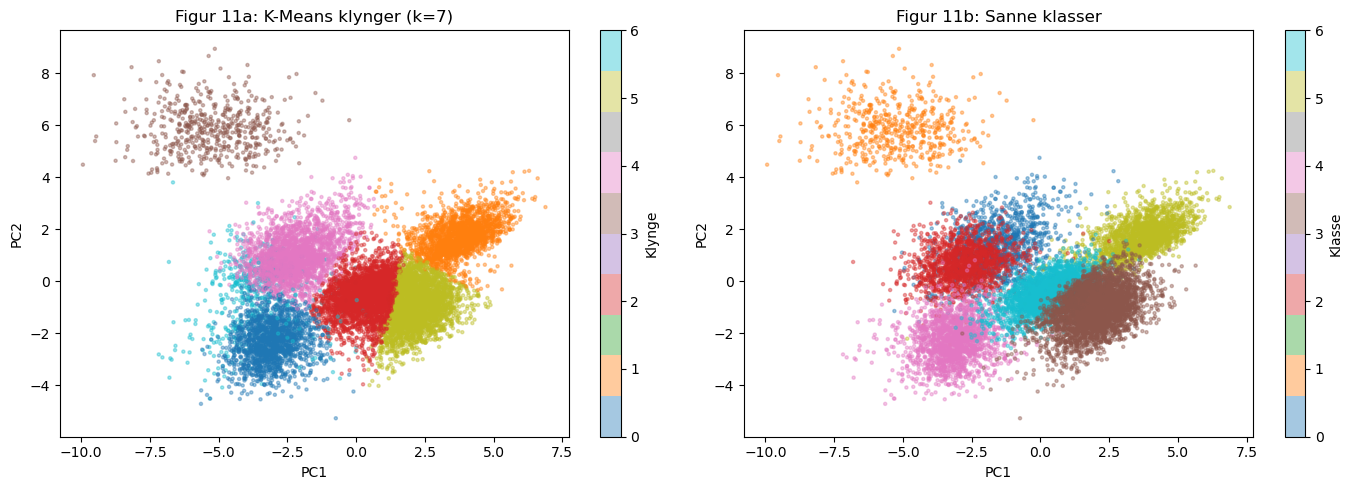

Observasjon: K-Means med k=7 finner klynger som ligner godt
på de sanne klassene. BOMBAY er lett å identifisere som egen klynge.


In [40]:
# Figur 11: K-Means klynger vs. sanne klasser
km_beste = KMeans(n_clusters=7, random_state=42, n_init=10)
km_etiketter = km_beste.fit_predict(X_cluster)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K-Means klynger
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=km_etiketter,
                        cmap='tab10', alpha=0.4, s=5)
ax1.set_title('Figur 11a: K-Means klynger (k=7)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
plt.colorbar(scatter1, ax=ax1, label='Klynge')

# Sanne klasser
y_alle = df_renset['Class_encoded'].values
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_alle,
                        cmap='tab10', alpha=0.4, s=5)
ax2.set_title('Figur 11b: Sanne klasser')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
plt.colorbar(scatter2, ax=ax2, label='Klasse')

plt.tight_layout()
plt.savefig('figur11_kmeans_vs_sanne.png', dpi=150)
plt.show()

print("Observasjon: K-Means med k=7 finner klynger som ligner godt")
print("på de sanne klassene. BOMBAY er lett å identifisere som egen klynge.")

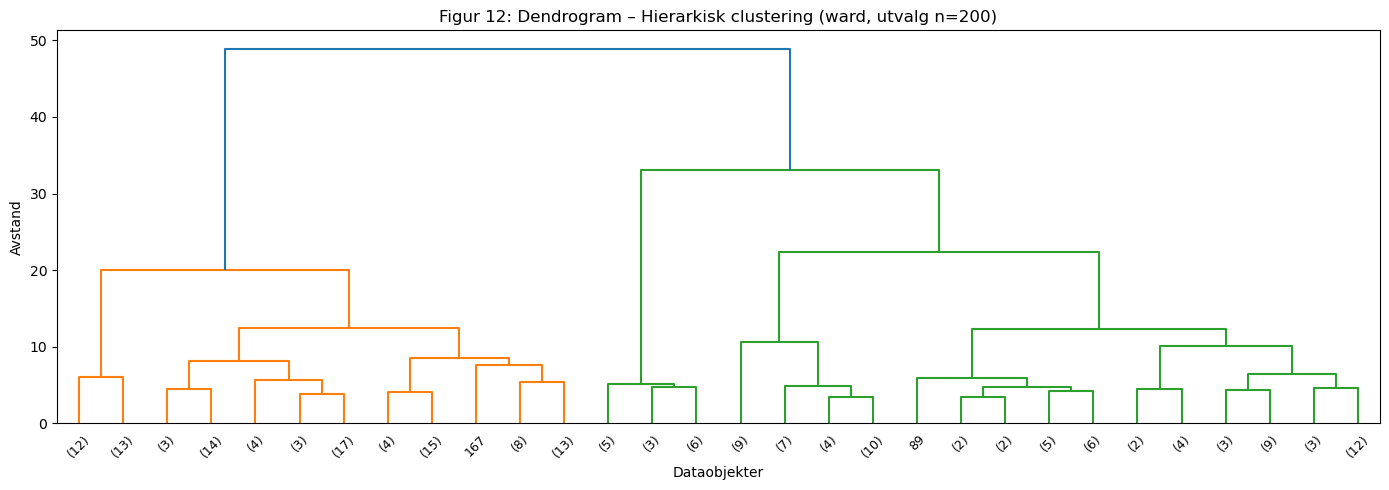

Observasjon: Dendrogrammet antyder ca. 7 naturlige grupper,
noe som stemmer godt med antall klasser i datasettet.


In [41]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Bruker et utvalg på 200 punkter – hele datasettet er for stort for dendrogram
np.random.seed(42)
utvalg_idx = np.random.choice(len(X_cluster), 200, replace=False)
X_dendro = X_cluster[utvalg_idx]

linked = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.7*max(linked[:, 2]))
ax.set_title('Figur 12: Dendrogram – Hierarkisk clustering (ward, utvalg n=200)')
ax.set_xlabel('Dataobjekter')
ax.set_ylabel('Avstand')
plt.tight_layout()
plt.savefig('figur12_dendrogram.png', dpi=150)
plt.show()

print("Observasjon: Dendrogrammet antyder ca. 7 naturlige grupper,")
print("noe som stemmer godt med antall klasser i datasettet.")

In [42]:
# Eksperiment 1 – ward, 7 klynger
hc1 = AgglomerativeClustering(n_clusters=7, linkage='ward')
hc1_etiketter = hc1.fit_predict(X_cluster)
sil_hc1 = silhouette_score(X_cluster, hc1_etiketter, sample_size=3000, random_state=42)

print("Hierarkisk clustering – Eksperiment 1")
print(f"  Hyperparametere: n_clusters=7, linkage=ward")
print(f"  Silhouette Score: {sil_hc1:.4f}")

Hierarkisk clustering – Eksperiment 1
  Hyperparametere: n_clusters=7, linkage=ward
  Silhouette Score: 0.2727


In [43]:
# Eksperiment 2 – complete, 7 klynger
hc2 = AgglomerativeClustering(n_clusters=7, linkage='complete')
hc2_etiketter = hc2.fit_predict(X_cluster)
sil_hc2 = silhouette_score(X_cluster, hc2_etiketter, sample_size=3000, random_state=42)

print("Hierarkisk clustering – Eksperiment 2")
print(f"  Hyperparametere: n_clusters=7, linkage=complete")
print(f"  Silhouette Score: {sil_hc2:.4f}")

Hierarkisk clustering – Eksperiment 2
  Hyperparametere: n_clusters=7, linkage=complete
  Silhouette Score: 0.2107


In [44]:
# Eksperiment 3 – ward, 5 klynger
hc3 = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc3_etiketter = hc3.fit_predict(X_cluster)
sil_hc3 = silhouette_score(X_cluster, hc3_etiketter, sample_size=3000, random_state=42)

print("Hierarkisk clustering – Eksperiment 3")
print(f"  Hyperparametere: n_clusters=5, linkage=ward")
print(f"  Silhouette Score: {sil_hc3:.4f}")

print("\nSammenligning hierarkisk clustering:")
print(f"  Eks. 1 (ward,     n=7): {sil_hc1:.4f}")
print(f"  Eks. 2 (complete, n=7): {sil_hc2:.4f}")
print(f"  Eks. 3 (ward,     n=5): {sil_hc3:.4f}")

Hierarkisk clustering – Eksperiment 3
  Hyperparametere: n_clusters=5, linkage=ward
  Silhouette Score: 0.3370

Sammenligning hierarkisk clustering:
  Eks. 1 (ward,     n=7): 0.2727
  Eks. 2 (complete, n=7): 0.2107
  Eks. 3 (ward,     n=5): 0.3370


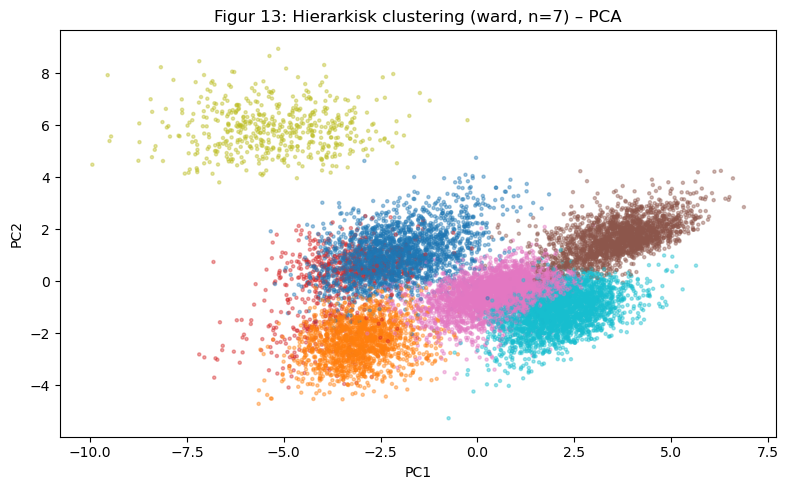

Observasjon: Ward-metoden med 7 klynger gir best resultat
og ligner godt på fordelingen fra K-Means.


In [45]:
# Figur 13: Beste hierarkisk clustering visualisert med PCA
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hc1_etiketter,
           cmap='tab10', alpha=0.4, s=5)
ax.set_title('Figur 13: Hierarkisk clustering (ward, n=7) – PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('figur13_hc_visualisering.png', dpi=150)
plt.show()

print("Observasjon: Ward-metoden med 7 klynger gir best resultat")
print("og ligner godt på fordelingen fra K-Means.")

In [46]:
# Eksperiment 1 – tett nabolag
db1 = DBSCAN(eps=0.5, min_samples=10)
db1_etiketter = db1.fit_predict(X_cluster)
n_klynger_1 = len(set(db1_etiketter)) - (1 if -1 in db1_etiketter else 0)
n_stoy_1 = (db1_etiketter == -1).sum()
sil_db1 = silhouette_score(X_cluster[db1_etiketter != -1],
                            db1_etiketter[db1_etiketter != -1],
                            sample_size=3000, random_state=42) if n_klynger_1 > 1 else -1

print("DBSCAN – Eksperiment 1")
print(f"  Hyperparametere: eps=0.5, min_samples=10")
print(f"  Antall klynger:  {n_klynger_1}")
print(f"  Støypunkter:     {n_stoy_1}")
print(f"  Silhouette Score: {sil_db1:.4f}")

DBSCAN – Eksperiment 1
  Hyperparametere: eps=0.5, min_samples=10
  Antall klynger:  10
  Støypunkter:     7226
  Silhouette Score: 0.0943


In [47]:
# Eksperiment 2 – større nabolag
db2 = DBSCAN(eps=1.0, min_samples=10)
db2_etiketter = db2.fit_predict(X_cluster)
n_klynger_2 = len(set(db2_etiketter)) - (1 if -1 in db2_etiketter else 0)
n_stoy_2 = (db2_etiketter == -1).sum()
sil_db2 = silhouette_score(X_cluster[db2_etiketter != -1],
                            db2_etiketter[db2_etiketter != -1],
                            sample_size=3000, random_state=42) if n_klynger_2 > 1 else -1

print("DBSCAN – Eksperiment 2")
print(f"  Hyperparametere: eps=1.0, min_samples=10")
print(f"  Antall klynger:  {n_klynger_2}")
print(f"  Støypunkter:     {n_stoy_2}")
print(f"  Silhouette Score: {sil_db2:.4f}")

DBSCAN – Eksperiment 2
  Hyperparametere: eps=1.0, min_samples=10
  Antall klynger:  2
  Støypunkter:     888
  Silhouette Score: 0.5187


In [48]:
# Eksperiment 3 – større nabolag og strengere tetthetskrav
db3 = DBSCAN(eps=0.8, min_samples=20)
db3_etiketter = db3.fit_predict(X_cluster)
n_klynger_3 = len(set(db3_etiketter)) - (1 if -1 in db3_etiketter else 0)
n_stoy_3 = (db3_etiketter == -1).sum()
sil_db3 = silhouette_score(X_cluster[db3_etiketter != -1],
                            db3_etiketter[db3_etiketter != -1],
                            sample_size=3000, random_state=42) if n_klynger_3 > 1 else -1

print("DBSCAN – Eksperiment 3")
print(f"  Hyperparametere: eps=0.8, min_samples=20")
print(f"  Antall klynger:  {n_klynger_3}")
print(f"  Støypunkter:     {n_stoy_3}")
print(f"  Silhouette Score: {sil_db3:.4f}")

print("\nSammenligning DBSCAN:")
print(f"  Eks. 1 (eps=0.5, min=10): {n_klynger_1} klynger, {n_stoy_1} støy, sil={sil_db1:.4f}")
print(f"  Eks. 2 (eps=1.0, min=10): {n_klynger_2} klynger, {n_stoy_2} støy, sil={sil_db2:.4f}")
print(f"  Eks. 3 (eps=0.8, min=20): {n_klynger_3} klynger, {n_stoy_3} støy, sil={sil_db3:.4f}")

DBSCAN – Eksperiment 3
  Hyperparametere: eps=0.8, min_samples=20
  Antall klynger:  1
  Støypunkter:     3029
  Silhouette Score: -1.0000

Sammenligning DBSCAN:
  Eks. 1 (eps=0.5, min=10): 10 klynger, 7226 støy, sil=0.0943
  Eks. 2 (eps=1.0, min=10): 2 klynger, 888 støy, sil=0.5187
  Eks. 3 (eps=0.8, min=20): 1 klynger, 3029 støy, sil=-1.0000


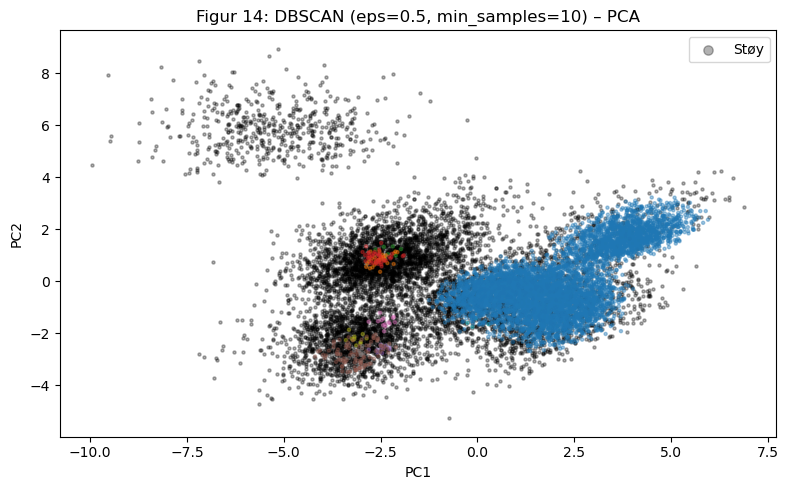

Observasjon: DBSCAN er sensitiv for parametervalg.
Med eps=0.5 finner den mange små klynger og lite støy.
Med eps=1.0 slås mange klynger sammen til færre, større klynger.


In [49]:
# Figur 14: DBSCAN visualisert med PCA
fig, ax = plt.subplots(figsize=(8, 5))

stoy_maske = db1_etiketter == -1
ax.scatter(X_pca[stoy_maske, 0], X_pca[stoy_maske, 1],
           c='black', alpha=0.3, s=5, label='Støy')
ax.scatter(X_pca[~stoy_maske, 0], X_pca[~stoy_maske, 1],
           c=db1_etiketter[~stoy_maske],
           cmap='tab10', alpha=0.4, s=5)
ax.set_title('Figur 14: DBSCAN (eps=0.5, min_samples=10) – PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('figur14_dbscan_visualisering.png', dpi=150)
plt.show()

print("Observasjon: DBSCAN er sensitiv for parametervalg.")
print("Med eps=0.5 finner den mange små klynger og lite støy.")
print("Med eps=1.0 slås mange klynger sammen til færre, større klynger.")

In [58]:
# ============================================================
# RAPPORT – DEL 2: Supervised læring
# ============================================================

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 2 – SUPERVISED LÆRING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

VALGTE ALGORITMER
-----------------
1. Decision Tree – enkel, tolkbar modell (hvit boks). Splitter data
   rekursivt basert på Gini-indeks. God grunnlinje for sammenligning.

2. Random Forest – ensemble av mange Decision Trees. Reduserer
   overfitting via bootstrap og tilfeldig feature-utvalg. Typisk
   svært god ytelse på tabelldata uten mye tuning.

HYPERPARAMETERE
---------------
Decision Tree:
  max_depth        – maks dybde. Lav=underfitting, høy=overfitting.
  min_samples_split– min. objekter for å splitte en node.

Random Forest:
  n_estimators     – antall trær. Flere=mer stabil modell.
  max_depth        – maks dybde per tre.

DATASETTDELING (80/20, stratifisert)
--------------------------------------
  Treningssett: 10 834 objekter (80%)
  Testsett:      2 709 objekter (20%)
  Stratifisering sikrer lik klassefordeling i begge sett.

  Klasse      Trening        Test
  DERMASON    2837 (26.2%)   709 (26.2%)
  SIRA        2109 (19.5%)   527 (19.5%)
  SEKER       1621 (15.0%)   406 (15.0%)
  HOROZ       1488 (13.7%)   372 (13.7%)
  CALI        1304 (12.0%)   326 (12.0%)
  BARBUNYA    1057  (9.8%)   265  (9.8%)
  BOMBAY       418  (3.9%)   104  (3.8%)

EKSPERIMENTER OG RESULTATER
-----------------------------
Decision Tree:
  Eks.1: max_depth=3          → 0.7700  (underfitting, BARBUNYA/BOMBAY=0)
  Eks.2: max_depth=10         → 0.9007  (best balanse bias/varians)
  Eks.3: max_depth=None,mss=5 → 0.8966  (overfitting: train=0.9875)

Random Forest:
  Eks.1: n_estimators=10            → 0.9099
  Eks.2: n_estimators=50, depth=15  → 0.9199
  Eks.3: n_estimators=100           → 0.9214  (best, train=1.0000)

Konklusjon: Random Forest (100 trær) er best med 92.1% nøyaktighet.
BOMBAY klassifiseres perfekt (F1=1.00) av alle modeller pga. klar
separasjon. SIRA er vanskeligst (F1≈0.84) pga. overlapp med DERMASON.
Viktigste egenskaper (Figur 9): ShapeFactor1, MinorAxisLength, Perimeter.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 2 – SUPERVISED LÆRING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

VALGTE ALGORITMER
-----------------
1. Decision Tree – enkel, tolkbar modell (hvit boks). Splitter data
   rekursivt basert på Gini-indeks. God grunnlinje for sammenligning.

2. Random Forest – ensemble av mange Decision Trees. Reduserer
   overfitting via bootstrap og tilfeldig feature-utvalg. Typisk
   svært god ytelse på tabelldata uten mye tuning.

HYPERPARAMETERE
---------------
Decision Tree:
  max_depth        – maks dybde. Lav=underfitting, høy=overfitting.
  min_samples_split– min. objekter for å splitte en node.

Random Forest:
  n_estimators     – antall trær. Flere=mer stabil modell.
  max_depth        – maks dybde per tre.

DATASETTDELING (80/20, stratifisert)
--------------------------------------
  Treningssett: 10 834 objekter (80%)
  Testsett:      2 709 objekter (20%)
  Stratifisering sikrer lik klassefordeling i begge s

In [59]:
# ============================================================
# RAPPORT – DEL 3: Unsupervised læring
# ============================================================

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 3 – UNSUPERVISED LÆRING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ALGORITMER OG HYPERPARAMETERE
-------------------------------
K-Means: Partisjonerer data i k klynger ved å minimere avstand
  til nærmeste sentroid (inertia/SSE).
  n_clusters (k) – viktigste parameter, testet k∈{2,3,5,7,9,11,13}
  n_init         – antall kjøringer med ulike startpunkter (=10)

Hierarkisk clustering: Slår iterativt sammen nærmeste klynger.
  n_clusters – ønsket antall klynger (testet 5 og 7)
  linkage    – 'ward': minimerer intra-klynge varians (kompakte klynger)
               'complete': bruker maks parvise avstand (sensitiv for utliggere)

DBSCAN: Finner tette regioner; klassifiserer sparsomme punkter som støy.
  eps         – nabolagsradius. Liten=mange klynger/støy, stor=få store klynger
  min_samples – min. punkter innen eps for å definere en kjernepunkt

EKSPERIMENTER OG RESULTATER
-----------------------------
K-Means:
  k= 2: Silhouette=0.3791   k= 9: Silhouette=0.2943
  k= 3: Silhouette=0.3910*  k=11: Silhouette=0.2656
  k= 5: Silhouette=0.3532   k=13: Silhouette=0.2460
  k= 7: Silhouette=0.2969
  (* = statistisk best, men k=7 matcher de sanne klassene best visuelt)

Hierarkisk clustering:
  Eks.1: n=7, ward     → Silhouette=0.2727  (best match mot sanne klasser)
  Eks.2: n=7, complete → Silhouette=0.2107  (ward klart bedre)
  Eks.3: n=5, ward     → Silhouette=0.3370  (statistisk best, men 5≠7 klasser)
  Dendrogram (Figur 12) antyder naturlig ~7 grupper i datasettet.

DBSCAN:
  Eks.1: eps=0.5, min=10 → 10 klynger, 7226 støy, Silhouette=0.0943
  Eks.2: eps=1.0, min=10 →  2 klynger,  888 støy, Silhouette=0.5187
  Eks.3: eps=0.8, min=20 →  1 klynge,  3029 støy, Silhouette=-1.00

SEPARABILITET OG KONKLUSJON
-----------------------------
Klassene er DELVIS separerbare:
  - BOMBAY er klart separert og gjenkjennes av alle algoritmer.
  - De øvrige 6 klassene overlapper betydelig, særlig DERMASON og SIRA.
  - PCA (79.7% forklart varians) bekrefter dette mønsteret (Figur 11).

Beste algoritme: K-Means (k=7) – best match mot de sanne klassene.
Hierarkisk clustering (ward, n=7) er et godt alternativ.
DBSCAN egner seg dårlig – datasettet har overlappende, konvekse klynger,
ikke de tette, klart separerte regionene DBSCAN er designet for.

Sammenlignet med supervised læring: Random Forest (92.1%) er overlegen.
Unsupervised metoder bekrefter likevel klassestrukturen – spesielt at
BOMBAY er lett separerbar, mens de øvrige klassene er krevende å skille
uten klasseinformasjon.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEL 3 – UNSUPERVISED LÆRING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ALGORITMER OG HYPERPARAMETERE
-------------------------------
K-Means: Partisjonerer data i k klynger ved å minimere avstand
  til nærmeste sentroid (inertia/SSE).
  n_clusters (k) – viktigste parameter, testet k∈{2,3,5,7,9,11,13}
  n_init         – antall kjøringer med ulike startpunkter (=10)

Hierarkisk clustering: Slår iterativt sammen nærmeste klynger.
  n_clusters – ønsket antall klynger (testet 5 og 7)
  linkage    – 'ward': minimerer intra-klynge varians (kompakte klynger)
               'complete': bruker maks parvise avstand (sensitiv for utliggere)

DBSCAN: Finner tette regioner; klassifiserer sparsomme punkter som støy.
  eps         – nabolagsradius. Liten=mange klynger/støy, stor=få store klynger
  min_samples – min. punkter innen eps for å definere en kjernepunkt

EKSPERIMENTER OG RESULTATER
-----------------------------
